In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# Preliminary phase data
df_gh1 = pd.read_csv('../data/raw/ghana/raw/prelims.csv')
df_ml1 = pd.read_csv('../data/raw/mali/raw/prelims.csv', sep=',')
df_tn1 = pd.read_csv('../data/raw/tanzania/raw/tanzania_prelim.csv')
df_ug1 = pd.read_csv('../data/raw/uganda/raw/prelims.csv')
df_zim1 = pd.read_csv('../data/raw/zim_zam/raw/zim.csv')
df_zam1 = pd.read_csv('../data/raw/zim_zam/raw/zam.csv')
df_zim_zam1 = pd.concat([df_zam1, df_zim1], ignore_index=True)

print('df_gh1:', df_gh1.shape)
print('df_ml1:', df_ml1.shape)
print('df_tn1:', df_tn1.shape)
print('df_ug2:', df_ug1.shape)
print('df_zim_zam1:', df_zim_zam1.shape)

df_gh1: (101, 82)
df_ml1: (104, 219)
df_tn1: (100, 52)
df_ug2: (154, 94)
df_zim_zam1: (200, 17)


In [4]:
#Quantitative phase data
df_gh2 = pd.read_csv('../data/raw/ghana/raw/ghana_phase_2.csv')
df_ml2 = pd.read_csv('../data/raw/mali/raw/mali_phase_2.csv', sep=';')
df_tn2 = pd.read_csv('../data/raw/tanzania/raw/tanzania_phase_2.csv')
df_ug2 = pd.read_csv('../data/raw/uganda/raw/uganda_phase_2.csv')
df_zim2 = pd.read_csv('../data/raw/zim_zam/raw/zim_phase_2.csv')
df_zam2 = pd.read_csv('../data/raw/zim_zam/raw/zam_phase_2.csv')
df_zim_zam2 = pd.concat([df_zam2, df_zim2], ignore_index=True)

print('df_gh2:', df_gh2.shape)
print('df_ml2:', df_ml2.shape)
print('df_tn2:', df_tn2.shape)
print('df_ug2:', df_ug2.shape)
print('df_zim_zam2:', df_zim_zam2.shape)

df_gh2: (999, 89)
df_ml2: (104, 219)
df_tn2: (900, 52)
df_ug2: (980, 88)
df_zim_zam2: (1000, 47)


In [5]:
df_gh2.shape[0]+df_ml2.shape[0]+df_tn2.shape[0]+df_ug2.shape[0]+df_zim_zam2.shape[0]

3983

In [6]:
df_gh2.head(2)

,record_id,facility_id_screening,nbs_screening_locale,participant_id,date_enrolled,date_of_visit,dob_guardian,pgage_yrs,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,comments,screening_date,kind_of_screening_test___1,kind_of_screening_test___2,kind_of_screening_test___3,kind_of_screening_test___4,kind_of_screening_test___5,kind_of_screening_test___6,alt_screening_test,tests___1,tests___2,tests___3,tests___4,tests___5,std_poct_done,std_poct_test_date,std_poct_test_result_date,std_poct_results,dbspoct_test_date,dbspoct_test_result_date,dbspoct_test_results,ief_test_date,ief_test_result_date,ief_test_results,hplc_test_date,hplc_result_date,hplc_results,additional_molecular_test,additional_test_date,add_molecular_result_date,add_molecula_test_results,newborn_registryid,reminder_1,reminder1_method___1,reminder1_method___2,reminder1_method___3,reminder1_method___4,alt_reminder1_method,reminder1_personnel,reminder_2,reminder2_method___1,reminder2_method___2,reminder2_method___3,reminder2_method___4,alt_reminder2_method,reminder2_personnel,reminder_3,reminder3_method___1,reminder3_method___2,reminder3_method___3,reminder3_method___4,alt_reminder3_method,reminder3_personnel,subject_comments
0,1,GH001,1,ML001,20 02 2024,20 02 2024,12 10 1996,NaN,1,Akan,2.0,NaN,4.0,3.0,NaN,5.0,Decorator,Christian,1.0,19 02 2024,0.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,No,20 02 2024,1,0,0,0,0,0,NaN,1,1,1,0,0,1.0,20 02 2024,20 02 2024,1.0,20 02 2024,28 03 2024,1.0,19 03 2024,19 03 2024,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN
1,2,GH001,1,ML002,20 02 2024,20 02 2024,NaN,NaN,1,Saliga,2.0,NaN,3.0,3.0,NaN,5.0,Seamstress,Muslim,3.0,19 02 2024,1.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,No,20 02 2024,1,0,0,0,0,0,NaN,1,1,1,0,0,1.0,20 02 2024,20 02 2024,3.0,20 02 2024,28 03 2024,1.0,19 03 2024,19 03 2024,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN


In [7]:
mapp = {
    'record_id': ['record_id', 'StudyID'],
    'facility_id': ['facility_id_screening', 'Facility ID'],
    'participant_id': ['participant_id', 'Study participant ID'],
    'date_enrolled': ['date_enrolled', 'Date subject signed consent (DD-MM-YY)'],
    'date_of_visit': ['date_of_visit', 'Date of visit'],
    'dob_guardian': ['dob_guardian', 'Date of birth (D-M-Y)'],
    'sex_guardian': ['sex_guardian', 'Sex'],
    'tribe_guardian': ['tribe_guardian', 'Tribe'],
    'guardian_relationship': ['guardian_relationship', 'Relationship of the guardian to the child'],
    'specify_relationship': ['specify_relationship', "If 'Other' please specify the relationship to the child"],
    'marital_status_guardian': ['marital_status_guardian', 'Marital status'],
    'edu_level_guardian': ['edu_level_guardian', 'Highest level of education completed'],
    'specify_edu_level_guardian': ['specify_edu_level_guardian', "If 'Other', please specify"],
    'guardian_occupation': ['guardian_occupation', 'Occupation'],
    'alt_guardian_occupation': ['alt_guardian_occupation', "If 'Other' occupation, please specify"],
    'religion': ['religion', 'Religion'],
    'mother_children_count': ['mother_children_count', 'Number of children of the mother of the newborn'],
    'dob_newborn': ['dob_newborn', 'Date of birth (D-M-Y).1'],
    'sex_newborn': ['sex_newborn', 'Sex.1'],
    'detection_at_birth': ['detection_at_birth', 'Sickle cell disease (SCD) can be detected at birth'],
    'scd_longevity': ['scd_longevity', 'People with SCD can live long lives'],
    'early_detection_importance': ['early_detection_importance', 'Early detection of SCD is need to provide adequate care for the affected child'],
    'need_immediate_result': ['need_immediate_result', 'It is important that a test for SCD for my child produces the result immediately'],
    'enough_poct_info': ['enough_poct_info', 'I have access to all the information I need on point of care tests for SCD'],
    'poct_result_speed': ['poct_result_speed', 'The result of a point of care test for SCD is available faster than for other screening methods'],
    'screening_recommendation': ['screening_recommendation', 'I would recommend the screening of babies for SCD at other healthcare facilities'],
    'poct_recommendation': ['poct_recommendation', 'I would recommend the use of point of care tests for SCD at other healthcare facilities'],
    'dbs_for_validation': ['dbs_for_validation', 'Alongside the point of care test, it is acceptable for a dried blood spot sample to be collected for validation'],
    'proper_treatment': ['proper_treatment', 'If someone tests positive for SCD at this healthcare facility it is important that they seek proper medical treatment, either here or at another facility'],
    'scd_in_the_family': ['scd_in_the_family', 'Do you have any family member with SCD?'],
    'registry_willingness': ['registry_willingness', 'If your baby tests positive, would you like to enrol the baby in SCD registry?'],
    'no_followup_reasons': ['no_followup_reasons', 'If your baby tests positive for SCD, would you be able to bring your baby back for follow-up?'],
    'nofollowup_reason_specified': ['nofollowup_reason_specified', "If 'No', please specify"],
    'screening_date': ['screening_date', 'Screening date (D-M-Y)'],
    'standard_poct': ['kind_of_screening_test___1'],
    'dbs_poct': ['kind_of_screening_test___2'],
    'ief': ['kind_of_screening_test___3'],
    'hplc': ['hplc', 'HPLC'],
    'molecular_testing': ['kind_of_screening_test___5'],
    'other': ['kind_of_screening_test___6'],
    'alt_screening_test': ['alt_screening_test'],
    'screening_test_done': ['Kind of screening test done (Please check all that apply)'],
    'std_poct_done': ['std_poct_done', 'Standard POCT done?'],
    'std_poct_test_date': ['std_poct_test_date', 'Date standard POCT test done (D-M-Y)'],
    'std_poct_test_result_date': ['std_poct_test_result_date', 'Date of Standard POCT results (D-M-Y)'],
    'std_poct_results': ['std_poct_results', 'Standard POCT Results'],
    'dbspoct_test_date': ['dbspoct_test_date', 'Date DBS-POCT test done (D-M-Y)'],
    'dbspoct_test_result_date': ['dbspoct_test_result_date', 'Date of DBS-POCT results (D-M-Y)'],
    'dbspoct_test_results': ['dbspoct_test_results', 'DBS-POCT Results'],
    'ief_test_date': ['ief_test_date', 'Date IEF test done (D-M-Y)'],
    'ief_test_result_date': ['ief_test_result_date', 'Date of IEF results (D-M-Y)'],
    'ief_test_results': ['ief_test_results', 'IEF Results'],
    'hplc_test_date': ['hplc_test_date', 'Date HPLC test done (D-M-Y)'],
    'hplc_result_date': ['hplc_result_date', 'Date of HPLC results (D-M-Y)'],
    'hplc_results': ['hplc_results', 'HPLC Results'],
    'additional_molecular_test': ['additional_molecular_test'],
    'additional_test_date': ['additional_test_date', 'Date additional molecular test done (D-M-Y)'],
    'add_molecular_result_date': ['add_molecular_result_date', 'Date of additional molecular results (D-M-Y)'],
    'add_molecula_test_results': ['add_molecula_test_results', 'Additional molecular test results']
}

In [8]:
df_gh2.head(2)

,record_id,facility_id_screening,nbs_screening_locale,participant_id,date_enrolled,date_of_visit,dob_guardian,pgage_yrs,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,comments,screening_date,kind_of_screening_test___1,kind_of_screening_test___2,kind_of_screening_test___3,kind_of_screening_test___4,kind_of_screening_test___5,kind_of_screening_test___6,alt_screening_test,tests___1,tests___2,tests___3,tests___4,tests___5,std_poct_done,std_poct_test_date,std_poct_test_result_date,std_poct_results,dbspoct_test_date,dbspoct_test_result_date,dbspoct_test_results,ief_test_date,ief_test_result_date,ief_test_results,hplc_test_date,hplc_result_date,hplc_results,additional_molecular_test,additional_test_date,add_molecular_result_date,add_molecula_test_results,newborn_registryid,reminder_1,reminder1_method___1,reminder1_method___2,reminder1_method___3,reminder1_method___4,alt_reminder1_method,reminder1_personnel,reminder_2,reminder2_method___1,reminder2_method___2,reminder2_method___3,reminder2_method___4,alt_reminder2_method,reminder2_personnel,reminder_3,reminder3_method___1,reminder3_method___2,reminder3_method___3,reminder3_method___4,alt_reminder3_method,reminder3_personnel,subject_comments
0,1,GH001,1,ML001,20 02 2024,20 02 2024,12 10 1996,NaN,1,Akan,2.0,NaN,4.0,3.0,NaN,5.0,Decorator,Christian,1.0,19 02 2024,0.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,No,20 02 2024,1,0,0,0,0,0,NaN,1,1,1,0,0,1.0,20 02 2024,20 02 2024,1.0,20 02 2024,28 03 2024,1.0,19 03 2024,19 03 2024,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN
1,2,GH001,1,ML002,20 02 2024,20 02 2024,NaN,NaN,1,Saliga,2.0,NaN,3.0,3.0,NaN,5.0,Seamstress,Muslim,3.0,19 02 2024,1.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,No,20 02 2024,1,0,0,0,0,0,NaN,1,1,1,0,0,1.0,20 02 2024,20 02 2024,3.0,20 02 2024,28 03 2024,1.0,19 03 2024,19 03 2024,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN


In [9]:
print("df_gh1:", df_gh1.shape)
print("df_ml1:", df_ml1.shape)
print("df_tn1:", df_tn1.shape)
print("df_ug1:", df_ug1.shape)
print("df_zim_zam1:", df_zim_zam1.shape)
print(' ')
print("df_gh2:", df_gh2.shape)
print("df_ml2:", df_ml2.shape)
print("df_tn2:", df_tn2.shape)
print("df_ug2:", df_ug2.shape)
print("df_zim_zam2:", df_zim_zam2.shape)

df_gh1: (101, 82)
df_ml1: (104, 219)
df_tn1: (100, 52)
df_ug1: (154, 94)
df_zim_zam1: (200, 17)
 
df_gh2: (999, 89)
df_ml2: (104, 219)
df_tn2: (900, 52)
df_ug2: (980, 88)
df_zim_zam2: (1000, 47)


In [10]:
rename_dict = {alias: key for key, aliases in mapp.items() for alias in aliases}

def harmonize_country(df1, df2, mapp, country_name, prefix):
    # Rename columns
    df1 = df1.rename(columns=rename_dict)
    df2 = df2.rename(columns=rename_dict)
    
    for col in mapp.keys():
        if col not in df1.columns:
            df1[col] = None
        if col not in df2.columns:
            df2[col] = None

    # Restrict to schema
    df1 = df1[list(mapp.keys())]
    df2 = df2[list(mapp.keys())]

    # Add metadata
    df1.loc[:, 'country'] = country_name
    df1.loc[:, 'record_id'] = prefix + df1['record_id'].astype(str)

    df2.loc[:, 'country'] = country_name
    df2['record_id'] = prefix + df2['record_id'].astype(str)

    # Show shapes
    print(f"{country_name} df1:", df1.shape)
    print(f"{country_name} df2:", df2.shape)
    print(' ')

    return df1, df2

In [11]:
df_gh1, df_gh2 = harmonize_country(df_gh1, df_gh2, mapp, 'Ghana', 'GH')
df_ml1, df_ml2 = harmonize_country(df_ml1, df_ml2, mapp, 'Mali', 'ML')
df_tn1, df_tn2 = harmonize_country(df_tn1, df_tn2, mapp, 'Tanzania', 'TN')
df_ug1, df_ug2 = harmonize_country(df_ug1, df_ug2, mapp, 'Uganda', 'UG')
df_zim_zam1, df_zim_zam2 = harmonize_country(df_zim_zam1, df_zim_zam2, mapp, 'Zimbabwe/Zambia', 'ZZ')

Ghana df1: (101, 60)
Ghana df2: (999, 60)
 
Mali df1: (104, 61)
Mali df2: (104, 61)
 
Tanzania df1: (100, 60)
Tanzania df2: (900, 60)
 
Uganda df1: (154, 60)
Uganda df2: (980, 60)
 
Zimbabwe/Zambia df1: (200, 60)
Zimbabwe/Zambia df2: (1000, 60)
 


In [12]:
def drop_duplicate_columns(df):
    # remove duplicate-named columns, keeping the first occurrence
    return df.loc[:, ~df.columns.duplicated(keep='first')]

df_gh1 = drop_duplicate_columns(df_gh1)
df_gh2 = drop_duplicate_columns(df_gh2)

df_ml1 = drop_duplicate_columns(df_ml1)
df_ml2 = drop_duplicate_columns(df_ml2)

df_tn1 = drop_duplicate_columns(df_tn1)
df_tn2 = drop_duplicate_columns(df_tn2)

df_ug1 = drop_duplicate_columns(df_ug1)
df_ug2 = drop_duplicate_columns(df_ug2)

df_zim_zam1 = drop_duplicate_columns(df_zim_zam1)
df_zim_zam2 = drop_duplicate_columns(df_zim_zam2)

In [13]:
df_phase_1 = pd.concat([df_gh1, df_ml1, df_tn1, df_ug1, df_zim_zam1], axis=0, ignore_index=True)
df_phase_2 = pd.concat([df_gh2, df_ml2, df_tn2, df_ug2, df_zim_zam2], axis=0, ignore_index=True)

print(df_phase_1.shape)
print(df_phase_2.shape)

(659, 60)
(3983, 60)


In [14]:
df_phase_2.head()

,record_id,facility_id,participant_id,date_enrolled,date_of_visit,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,screening_date,standard_poct,dbs_poct,ief,hplc,molecular_testing,other,alt_screening_test,screening_test_done,std_poct_done,std_poct_test_date,std_poct_test_result_date,std_poct_results,dbspoct_test_date,dbspoct_test_result_date,dbspoct_test_results,ief_test_date,ief_test_result_date,ief_test_results,hplc_test_date,hplc_result_date,hplc_results,additional_molecular_test,additional_test_date,add_molecular_result_date,add_molecula_test_results,country
0,GH1,GH001,ML001,20 02 2024,20 02 2024,12 10 1996,1,Akan,2.0,NaN,4.0,3.0,NaN,5.0,Decorator,Christian,1.0,19 02 2024,0.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,20 02 2024,1,0,0,None,0,0,NaN,None,1.0,20 02 2024,20 02 2024,1.0,20 02 2024,28 03 2024,1.0,19 03 2024,19 03 2024,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ghana
1,GH2,GH001,ML002,20 02 2024,20 02 2024,NaN,1,Saliga,2.0,NaN,3.0,3.0,NaN,5.0,Seamstress,Muslim,3.0,19 02 2024,1.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,20 02 2024,1,0,0,None,0,0,NaN,None,1.0,20 02 2024,20 02 2024,3.0,20 02 2024,28 03 2024,1.0,19 03 2024,19 03 2024,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ghana
2,GH3,GH001,ML003,20 02 2024,20 02 2024,28 09 1991,1,Frafra,2.0,NaN,3.0,2.0,NaN,5.0,Seamstress,Muslim,2.0,19 02 2024,0.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,20 02 2024,1,0,0,None,0,0,NaN,None,1.0,20 02 2024,20 02 2024,1.0,22 02 2024,28 03 2024,1.0,13 03 2024,13 03 2024,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ghana
3,GH4,GH001,ML004,20 02 2024,20 02 2024,NaN,1,Fulani,2.0,NaN,3.0,4.0,NaN,5.0,Seamstress,Muslim,1.0,9 01 2024,1.0,5.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,2.0,1.0,1.0,NaN,20 02 2024,1,0,0,None,0,0,NaN,None,1.0,20 02 2024,20 02 2024,2.0,20 02 2024,28 03 2024,2.0,13 03 2024,13 03 2024,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ghana
4,GH5,GH001,ML005,21 02 2024,21 02 2024,1 01 1993,1,Songhai,2.0,NaN,3.0,1.0,NaN,3.0,NaN,Muslim,7.0,21 02 2024,0.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,NaN,21 02 2024,1,0,0,None,0,0,NaN,None,1.0,21 02 2024,21 02 2024,1.0,21 02 2024,28 03 2024,1.0,13 03 2024,13 03 2024,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ghana


In [15]:
df_phase_2.columns

Index(['record_id', 'facility_id', 'participant_id', 'date_enrolled',
       'date_of_visit', 'dob_guardian', 'sex_guardian', 'tribe_guardian',
       'guardian_relationship', 'specify_relationship',
       'marital_status_guardian', 'edu_level_guardian',
       'specify_edu_level_guardian', 'guardian_occupation',
       'alt_guardian_occupation', 'religion', 'mother_children_count',
       'dob_newborn', 'sex_newborn', 'detection_at_birth', 'scd_longevity',
       'early_detection_importance', 'need_immediate_result',
       'enough_poct_info', 'poct_result_speed', 'screening_recommendation',
       'poct_recommendation', 'dbs_for_validation', 'proper_treatment',
       'scd_in_the_family', 'registry_willingness', 'no_followup_reasons',
       'nofollowup_reason_specified', 'screening_date', 'standard_poct',
       'dbs_poct', 'ief', 'hplc', 'molecular_testing', 'other',
       'alt_screening_test', 'screening_test_done', 'std_poct_done',
       'std_poct_test_date', 'std_poct_test_re

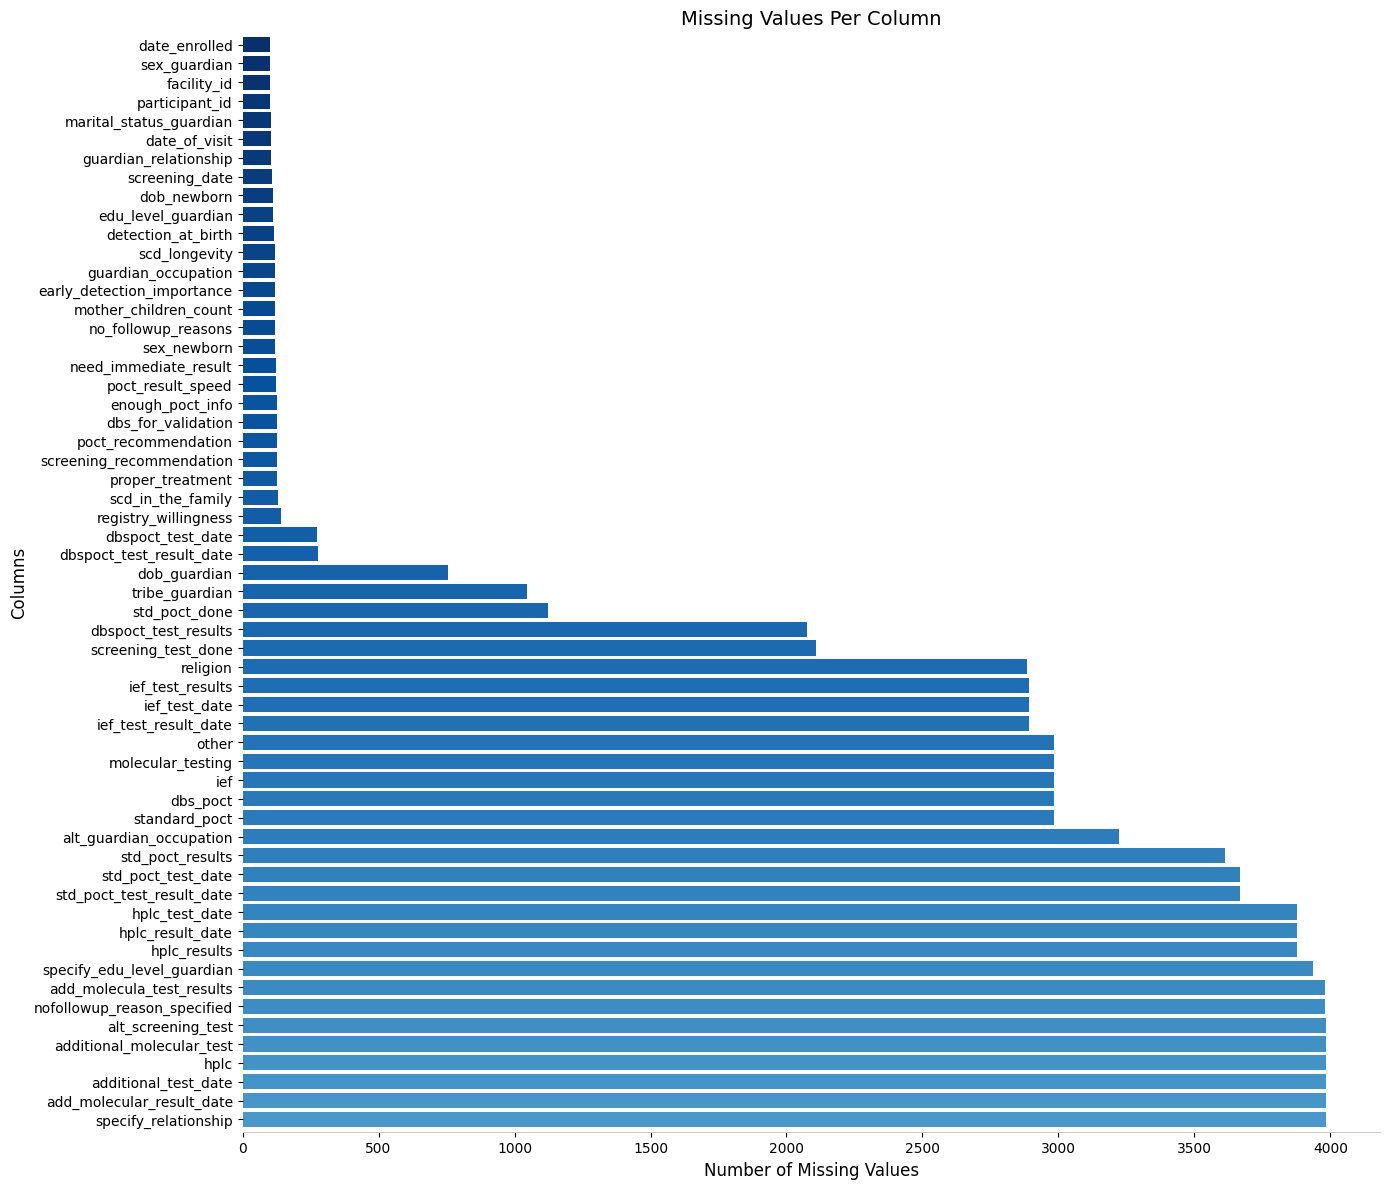

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Count missing values in each column
missing_summary = df_phase_2.isnull().sum()

# Filter for columns with missing values
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

# Create a color gradient (blue shades)
colors = plt.cm.Blues(np.linspace(0.6, 1, len(missing_summary)))

# Adjust figure size for more vertical space
plt.figure(figsize=(14, 12))  # Increased height

# Plot missing values as a horizontal bar chart
missing_summary.plot(kind='barh', color=colors, width=0.8)  # Thicker bars

# Modern styling
plt.title('Missing Values Per Column', fontsize=14)
plt.xlabel('Number of Missing Values', fontsize=12)
plt.ylabel('Columns', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Remove borders around bars
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_color('#cccccc')  # Light gray bottom border for subtle styling

# Improve layout
plt.tight_layout()

# Save the plot as a file
plt.savefig("figures/eda/missing_values_plot.png", dpi=300, bbox_inches='tight')  # Save as PNG with high resolution

# Show the plot
plt.show()

In [17]:
# List of questionnaire-related variables
questionnaire_vars = [
    'dob_guardian','sex_guardian','guardian_relationship', 'detection_at_birth', 'scd_longevity', 
    'early_detection_importance','need_immediate_result', 'enough_poct_info', 'poct_result_speed',
    'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
    'proper_treatment', 'scd_in_the_family', 'registry_willingness',
    'no_followup_reasons', 'nofollowup_reason_specified', 'screening_date'
]

# Add 'country' and 'facility_id' to the list
columns_to_keep = questionnaire_vars + ['country', 'facility_id','participant_id', 'record_id']

# Filter the DataFrame
df_questionnaire = df_phase_2[columns_to_keep]

column_order = [
    'record_id', 'participant_id', 'facility_id','screening_date', 'dob_guardian','sex_guardian', 'guardian_relationship',
    'detection_at_birth', 'scd_longevity', 'early_detection_importance',
    'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
    'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
    'proper_treatment', 'scd_in_the_family', 'registry_willingness',
    'no_followup_reasons', 'nofollowup_reason_specified', 'country'
]

# Reorder columns in the DataFrame
df_questionnaire = df_questionnaire[column_order]

# Display the shape and first few rows of the new DataFrame
print('Filtered DataFrame shape:', df_questionnaire.shape)

Filtered DataFrame shape: (3983, 22)


In [18]:
print('Filtered DataFrame shape:', df_questionnaire.shape)
df_questionnaire.head()

Filtered DataFrame shape: (3983, 22)


,record_id,participant_id,facility_id,screening_date,dob_guardian,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,GH1,ML001,GH001,20 02 2024,12 10 1996,1,2.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,Ghana
1,GH2,ML002,GH001,20 02 2024,NaN,1,2.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,Ghana
2,GH3,ML003,GH001,20 02 2024,28 09 1991,1,2.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,Ghana
3,GH4,ML004,GH001,20 02 2024,NaN,1,2.0,5.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,2.0,1.0,1.0,NaN,Ghana
4,GH5,ML005,GH001,21 02 2024,1 01 1993,1,2.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,NaN,Ghana


In [19]:
df_questionnaire.shape

(3983, 22)

In [20]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Count missing values in each column
# missing_summary = df_questionnaire.isnull().sum()

# # Filter for columns with missing values
# missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

# # Create a color gradient (blue shades)
# colors = plt.cm.Blues(np.linspace(0.6, 1, len(missing_summary)))

# # Adjust figure size for more vertical space
# plt.figure(figsize=(14, 12))  # Increased height

# # Plot missing values as a horizontal bar chart
# missing_summary.plot(kind='barh', color=colors, width=0.8)  # Thicker bars

# # Modern styling
# plt.title('Missing Values Per Questionnaire Column (Guardian)', fontsize=14)
# plt.xlabel('Number of Missing Values', fontsize=12)
# plt.ylabel('Columns', fontsize=12)
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)

# # Remove top and right borders
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)

# # Remove borders around bars
# plt.gca().spines['left'].set_visible(False)
# plt.gca().spines['bottom'].set_color('#cccccc')  # Light gray bottom border for subtle styling

# # Improve layout
# plt.tight_layout()

# # Save the plot as a file
# plt.savefig("figures/eda/missing_values_questionnaire.png", dpi=300, bbox_inches='tight')  # Save as PNG with high resolution

# # Show the plot
# plt.show()

In [21]:
df_questionnaire.shape

(3983, 22)

In [22]:
df_questionnaire.head()

,record_id,participant_id,facility_id,screening_date,dob_guardian,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,GH1,ML001,GH001,20 02 2024,12 10 1996,1,2.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,Ghana
1,GH2,ML002,GH001,20 02 2024,NaN,1,2.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,Ghana
2,GH3,ML003,GH001,20 02 2024,28 09 1991,1,2.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,Ghana
3,GH4,ML004,GH001,20 02 2024,NaN,1,2.0,5.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,2.0,1.0,1.0,NaN,Ghana
4,GH5,ML005,GH001,21 02 2024,1 01 1993,1,2.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,NaN,Ghana


In [23]:
for col in df_questionnaire.columns:
    print(f"Column: {col}")
    print(df_questionnaire[col].value_counts(dropna=False))
    print("-" * 40)  # Separator for readability

Column: record_id
record_id
ZZnan        100
TN900          2
GH1            1
UG1550         1
UG1552         1
UG1513         1
UG1514         1
UG1515         1
UG1516         1
UG1517         1
UG1518         1
UG928          1
UG929          1
UG930          1
UG931          1
UG932          1
UG949          1
UG933          1
UG934          1
UG936          1
UG937          1
UG938          1
UG939          1
UG940          1
UG941          1
UG942          1
UG943          1
UG944          1
UG945          1
UG947          1
UG1548         1
UG1549         1
UG1547         1
UG1546         1
UG1520         1
UG1521         1
UG1522         1
UG1523         1
UG1524         1
UG1529         1
UG1525         1
UG1526         1
UG1527         1
UG1528         1
UG1530         1
UG1532         1
UG1531         1
UG1533         1
UG1534         1
UG1535         1
UG1540         1
UG1541         1
UG1536         1
UG1537         1
UG1538         1
UG1539         1
UG1939         1
UG1

participant_id
NaN                102
LRRH/NBS/0715        2
NBSZIM242            2
LRRH/NBS/0064        2
NBS/BXZ1IH           2
0004                 2
NBSZIM               2
NBS/BXZ17G           2
NBS/BXZ1HG           2
NBSZIM132            2
NBS/BXZ1AC           2
LRRH/NBS/0029        2
LRRH/NBS/0596        1
LRRH/NBS/0599        1
LRRH/NBS/0598        1
LRRH/NBS/0597        1
LRRH/NBS/0595        1
LRRH/NBS/0601        1
LRRH/NBS/0594        1
LRRH/NBS/0593        1
LRRH/NBS/0600        1
ML001                1
LRRH/NBS/0602        1
LRRH/NBS/0603        1
LRRH/NBS/0604        1
LRRH/NBS/0605        1
LRRH/NBS/0592        1
LRRH/NBS/0607        1
LRRH/NBS/0608        1
LRRH/NBS/0609        1
LRRH/NBS/0610        1
LRRH/NBS/0611        1
LRRH/NBS/0612        1
LRRH/NBS/0613        1
LRRH/NBS/0606        1
LRRH/NBS/0589        1
LRRH/NBS/0591        1
LRRH/NBS/0576        1
LRRH/NBS/0563        1
LRRH/NBS/0564        1
LRRH/NBS/0565        1
LRRH/NBS/0566        1
LRRH/NBS/0567      

In [24]:
df_questionnaire.columns

Index(['record_id', 'participant_id', 'facility_id', 'screening_date',
       'dob_guardian', 'sex_guardian', 'guardian_relationship',
       'detection_at_birth', 'scd_longevity', 'early_detection_importance',
       'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
       'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
       'proper_treatment', 'scd_in_the_family', 'registry_willingness',
       'no_followup_reasons', 'nofollowup_reason_specified', 'country'],
      dtype='object')

In [25]:
# Define the general mapping dictionary
value_map_general = {
    'Strongly Disagree': 1.0,
    'Disagree': 2.0,
    'Neutral/ I don\'t know': 3.0,
    'I don\'t know': 3.0,
    'Agree': 4.0,
    'Strongly Agree': 5.0,
    'Yes': 1.0,
    'No': 0.0,
    'Oui': 1.0  # If applicable for 'Oui'
}

# Columns to map
columns_to_map = [
    'detection_at_birth', 'scd_longevity', 'early_detection_importance',
    'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
    'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
    'proper_treatment', 'scd_in_the_family', 'registry_willingness',
    'no_followup_reasons'
]

# Apply the mapping to all specified columns
for col in columns_to_map:
    df_questionnaire[col] = df_questionnaire[col].replace(value_map_general)

In [26]:
df_questionnaire.head()

,record_id,participant_id,facility_id,screening_date,dob_guardian,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,GH1,ML001,GH001,20 02 2024,12 10 1996,1,2.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,Ghana
1,GH2,ML002,GH001,20 02 2024,NaN,1,2.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,Ghana
2,GH3,ML003,GH001,20 02 2024,28 09 1991,1,2.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,Ghana
3,GH4,ML004,GH001,20 02 2024,NaN,1,2.0,5.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,2.0,1.0,1.0,NaN,Ghana
4,GH5,ML005,GH001,21 02 2024,1 01 1993,1,2.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,NaN,Ghana


In [27]:
value_map_general = {
    'Strongly Disagree': 1.0,
    'Disagree': 2.0,
    'Neutral/ I don\'t know': 3.0,
    'I don\'t know': 3.0,
    'Agree': 4.0,
    'Strongly Agree': 5.0,
    'Yes': 1.0,
    'No': 0.0,
    'Oui': 1.0  
}

value_map_guardian = {
    'Father': 1.0,
    'Mother': 2.0,
    'Aunt': 3.0,
    'Uncle': 4.0,
    'Grandparent': 5.0,
    'Sister': 6.0,
    'Brother': 7.0,
    'Cousin': 8.0,
    'Other': 9.0 
}

# Columns to map
columns_to_map = [
    'detection_at_birth', 'scd_longevity', 'early_detection_importance',
    'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
    'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
    'proper_treatment', 'scd_in_the_family', 'registry_willingness',
    'no_followup_reasons'
]

# Apply the mapping to all specified columns
for col in columns_to_map:
    df_questionnaire[col] = df_questionnaire[col].replace(value_map_general)
    df_questionnaire[col] = pd.to_numeric(df_questionnaire[col], errors='coerce').astype('Int64')
    
df_questionnaire['guardian_relationship'] = df_questionnaire['guardian_relationship'].replace(value_map_guardian)
df_questionnaire['guardian_relationship'] = pd.to_numeric(df_questionnaire['guardian_relationship'], \
                                                          errors='coerce').astype('Int64')

In [28]:
df_questionnaire.columns

Index(['record_id', 'participant_id', 'facility_id', 'screening_date',
       'dob_guardian', 'sex_guardian', 'guardian_relationship',
       'detection_at_birth', 'scd_longevity', 'early_detection_importance',
       'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
       'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
       'proper_treatment', 'scd_in_the_family', 'registry_willingness',
       'no_followup_reasons', 'nofollowup_reason_specified', 'country'],
      dtype='object')

In [29]:
# 1) Columns that are entirely missing (global)
all_missing_cols = df_questionnaire.columns[df_questionnaire.isna().all()].tolist()
print(f"All-missing columns ({len(all_missing_cols)}):\n", all_missing_cols)

df_questionnaire_clean = df_questionnaire.drop(columns=all_missing_cols)

THRESH = 0.95
missing_frac = df_questionnaire.isna().mean().sort_values(ascending=False)
near_all_missing = missing_frac[missing_frac >= THRESH].index.tolist()
print(f"\nNear-all-missing (≥{int(THRESH*100)}% missing) ({len(near_all_missing)}):\n", near_all_missing)

missing_summary = pd.DataFrame({
    'n_missing': df_questionnaire.isna().sum(),
    'pct_missing': df_questionnaire.isna().mean()
}).sort_values('pct_missing', ascending=False)
print("\nMissingness summary (top 20):")
print(missing_summary.head(20))

All-missing columns (0):
 []

Near-all-missing (≥95% missing) (1):
 ['nofollowup_reason_specified']

Missingness summary (top 20):
                             n_missing  pct_missing
nofollowup_reason_specified       3981     0.999498
dob_guardian                       756     0.189807
registry_willingness               142     0.035652
scd_in_the_family                  130     0.032639
proper_treatment                   128     0.032137
screening_recommendation           128     0.032137
poct_recommendation                126     0.031634
enough_poct_info                   125     0.031383
dbs_for_validation                 125     0.031383
poct_result_speed                  122     0.030630
need_immediate_result              122     0.030630
no_followup_reasons                121     0.030379
early_detection_importance         120     0.030128
scd_longevity                      118     0.029626
detection_at_birth                 117     0.029375
screening_date                     10

In [30]:
df_questionnaire.head()

,record_id,participant_id,facility_id,screening_date,dob_guardian,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,GH1,ML001,GH001,20 02 2024,12 10 1996,1,2,3,2,4,5,5,4,5,5,4,5,2,1,1,NaN,Ghana
1,GH2,ML002,GH001,20 02 2024,NaN,1,2,5,2,4,5,5,3,5,5,5,5,3,1,1,NaN,Ghana
2,GH3,ML003,GH001,20 02 2024,28 09 1991,1,2,3,2,4,5,5,5,5,5,4,5,2,1,1,NaN,Ghana
3,GH4,ML004,GH001,20 02 2024,NaN,1,2,5,4,5,2,5,4,5,5,5,5,2,1,1,NaN,Ghana
4,GH5,ML005,GH001,21 02 2024,1 01 1993,1,2,4,3,3,3,4,4,4,4,4,4,2,1,1,NaN,Ghana


In [31]:
df_questionnaire['nofollowup_reason_specified'].value_counts()

nofollowup_reason_specified
LIVING IN TANGA     1
4.0                 1
Name: count, dtype: int64

In [32]:
# Guardian questions
columns_to_map

['detection_at_birth',
 'scd_longevity',
 'early_detection_importance',
 'need_immediate_result',
 'enough_poct_info',
 'poct_result_speed',
 'screening_recommendation',
 'poct_recommendation',
 'dbs_for_validation',
 'proper_treatment',
 'scd_in_the_family',
 'registry_willingness',
 'no_followup_reasons']

In [33]:
sex_guardian_scales = {0: 'Male', 1: 'Female'}

guardian_relationship_scales = {
    1: 'Father', 2: 'Mother', 3: 'Aunt', 4: 'Uncle', 5: 'Grandparent',
    6: 'Sister', 7: 'Brother', 8: 'SCousin', 9: 'Other'
}

scd_in_the_family_scales = {1: 'Yes', 2: 'No', 3: "I don't know"}
registry_willingness_scales = {1: 'Yes', 2: 'No'}
no_followup_reasons_scales = {1: 'Yes', 2: 'No'}

value_map_likert_scales = {
    1: 'Strongly Disagree', 2: 'Disagree', 3: 'Neutral',
    4: 'Agree', 5: 'Strongly Agree'
}

LIKERT_COLS = [
    'detection_at_birth','scd_longevity','early_detection_importance',
    'need_immediate_result','enough_poct_info','poct_result_speed',
    'screening_recommendation','poct_recommendation',
    'dbs_for_validation','proper_treatment'
]
likert_cols_named = [c for c in LIKERT_COLS if c in df_questionnaire.columns]

def is_likert_series(s: pd.Series) -> bool:
    vals = pd.to_numeric(s.dropna(), errors='coerce')
    vals = vals[~vals.isna()]
    if vals.empty: return False
    u = set(vals.astype(int))
    return u.issubset({1,2,3,4,5}) and len(u) >= 3

likert_cols_auto = [c for c in df_questionnaire.columns if is_likert_series(df_questionnaire[c])]
likert_cols = sorted(set(likert_cols_named) | set(likert_cols_auto))

# --- Helper: map numeric codes → labels, preserving existing strings; then optional categorical ---
def apply_scale_preserve(df, col, scale_map, ordered=False, categories=None):
    if col not in df.columns:
        return
    # ensure column can hold strings
    df[col] = df[col].astype('object')

    # map only numeric-like entries
    nums = pd.to_numeric(df[col], errors='coerce')
    mask = nums.notna()
    mapped = nums.map(scale_map)
    df.loc[mask, col] = mapped

    # decide categories
    if categories is None:
        categories = list(scale_map.values())

    # cast to categorical only if all values are within categories
    non_null_vals = pd.Series(df[col].dropna().unique())
    if non_null_vals.empty or set(non_null_vals).issubset(set(categories)):
        dtype = pd.api.types.CategoricalDtype(categories=categories, ordered=ordered)
        df[col] = df[col].astype(dtype)

# --- Apply to non-Likert fields ---
apply_scale_preserve(
    df_questionnaire, 'sex_guardian',
    sex_guardian_scales, ordered=True, categories=['Male','Female']
)

apply_scale_preserve(
    df_questionnaire, 'guardian_relationship',
    guardian_relationship_scales, ordered=True,
    categories=[guardian_relationship_scales[i] for i in sorted(guardian_relationship_scales)]
)

apply_scale_preserve(
    df_questionnaire, 'scd_in_the_family',
    scd_in_the_family_scales, ordered=True, categories=['Yes','No',"I don't know"]
)

apply_scale_preserve(
    df_questionnaire, 'registry_willingness',
    registry_willingness_scales, ordered=True, categories=['Yes','No']
)

apply_scale_preserve(
    df_questionnaire, 'no_followup_reasons',
    no_followup_reasons_scales, ordered=True, categories=['Yes','No']
)

df_questionnaire[likert_cols] = (
    df_questionnaire[likert_cols].astype('object').replace(value_map_likert_scales)
)

likert_cat = pd.api.types.CategoricalDtype(
    categories=['Strongly Disagree','Disagree','Neutral','Agree','Strongly Agree'],
    ordered=True
)
for c in likert_cols:
    non_null_vals = pd.Series(df_questionnaire[c].dropna().unique())
    if non_null_vals.empty or set(non_null_vals).issubset(set(likert_cat.categories)):
        df_questionnaire[c] = df_questionnaire[c].astype(likert_cat)

In [34]:
s = (
    df_questionnaire['screening_date']
      .astype('string')          # handles categories / ints safely
      .str.strip()
      .str.replace(r'[./,-]', ' ', regex=True)   # normalize separators
      .str.replace(r'\s+', ' ', regex=True)
)

# First pass: generic parser with day-first
dt = pd.to_datetime(s, dayfirst=True, errors='coerce')

# Fallback A: 8-digit DDMMYYYY with no separators
mask8 = dt.isna() & s.str.fullmatch(r'\d{8}', na=False)
if mask8.any():
    s8 = s.loc[mask8].str.replace(r'(\d{2})(\d{2})(\d{4})', r'\1-\2-\3', regex=True)
    dt.loc[mask8] = pd.to_datetime(s8, dayfirst=True, errors='coerce')

# Fallback B: Excel serial dates (5–6 digits, e.g., 45210)
mask_serial = dt.isna() & s.str.fullmatch(r'\d{5,6}', na=False)
if mask_serial.any():
    base = pd.Timestamp('1899-12-30')
    dt.loc[mask_serial] = base + pd.to_timedelta(s.loc[mask_serial].astype(int), unit='D')

# ---------- 2) Plausibility window (adjust as needed) ----------
min_date = pd.Timestamp('2015-01-01')
max_date = pd.Timestamp.today().normalize() + pd.Timedelta(days=30)
dt = dt.where((dt >= min_date) & (dt <= max_date))

# ---------- 3) Optional: fall back to date_of_visit if screening_date failed ----------
if 'date_of_visit' in df_questionnaire.columns:
    dov = (
        df_questionnaire['date_of_visit']
          .astype('string').str.strip()
          .str.replace(r'[./,-]', ' ', regex=True)
          .str.replace(r'\s+', ' ', regex=True)
    )
    dov_dt = pd.to_datetime(dov, dayfirst=True, errors='coerce')
    dt = dt.fillna(dov_dt)

df_questionnaire['screening_date'] = dt

In [35]:
dob = pd.to_datetime(df_questionnaire['dob_guardian'], errors='coerce')
ref = pd.to_datetime(df_questionnaire['screening_date'], errors='coerce')

# If screening_date is missing, optionally fall back to date_of_visit / date_enrolled
if ref.isna().all() and 'date_of_visit' in df_questionnaire:
    ref = pd.to_datetime(df_questionnaire['date_of_visit'], errors='coerce').where(ref.isna(), ref)
if ref.isna().all() and 'date_enrolled' in df_questionnaire:
    ref = pd.to_datetime(df_questionnaire['date_enrolled'], errors='coerce').where(ref.isna(), ref)

td = ref - dob
age_years = td.dt.days / 365.25

# Keep plausible ages only (10–80 inclusive)
valid_mask = age_years.ge(10) & age_years.le(80)

dob_valid = dob.where(valid_mask)          # invalid ages -> NaT
age_valid = age_years.where(valid_mask)    # invalid ages -> NaN

# Write back
df_questionnaire['dob_guardian'] = dob_valid
# df_questionnaire['dob_guardian_iso'] = dob_valid.dt.strftime('%Y-%m-%d')
df_questionnaire['guardian_age'] = age_valid.round(1)
df_questionnaire.insert(5, 'guardian_age', df_questionnaire.pop('guardian_age'))

In [36]:
print(df_questionnaire.shape)
df_questionnaire.head()

(3983, 23)


,record_id,participant_id,facility_id,screening_date,dob_guardian,guardian_age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,GH1,ML001,GH001,2024-02-20,1996-12-10,27.2,Female,Mother,Neutral,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
1,GH2,ML002,GH001,2024-02-20,NaT,NaN,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,Ghana
2,GH3,ML003,GH001,2024-02-20,NaT,NaN,Female,Mother,Neutral,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
3,GH4,ML004,GH001,2024-02-20,NaT,NaN,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
4,GH5,ML005,GH001,2024-02-21,1993-01-01,31.1,Female,Mother,Agree,Neutral,Neutral,Neutral,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,Ghana


### EDA

In [37]:
df_questionnaire['country'].value_counts(dropna=False)

country
Zimbabwe/Zambia    1000
Ghana               999
Uganda              980
Tanzania            900
Mali                104
Name: count, dtype: int64

In [38]:
df_questionnaire['country'].value_counts(dropna=False)

country
Zimbabwe/Zambia    1000
Ghana               999
Uganda              980
Tanzania            900
Mali                104
Name: count, dtype: int64

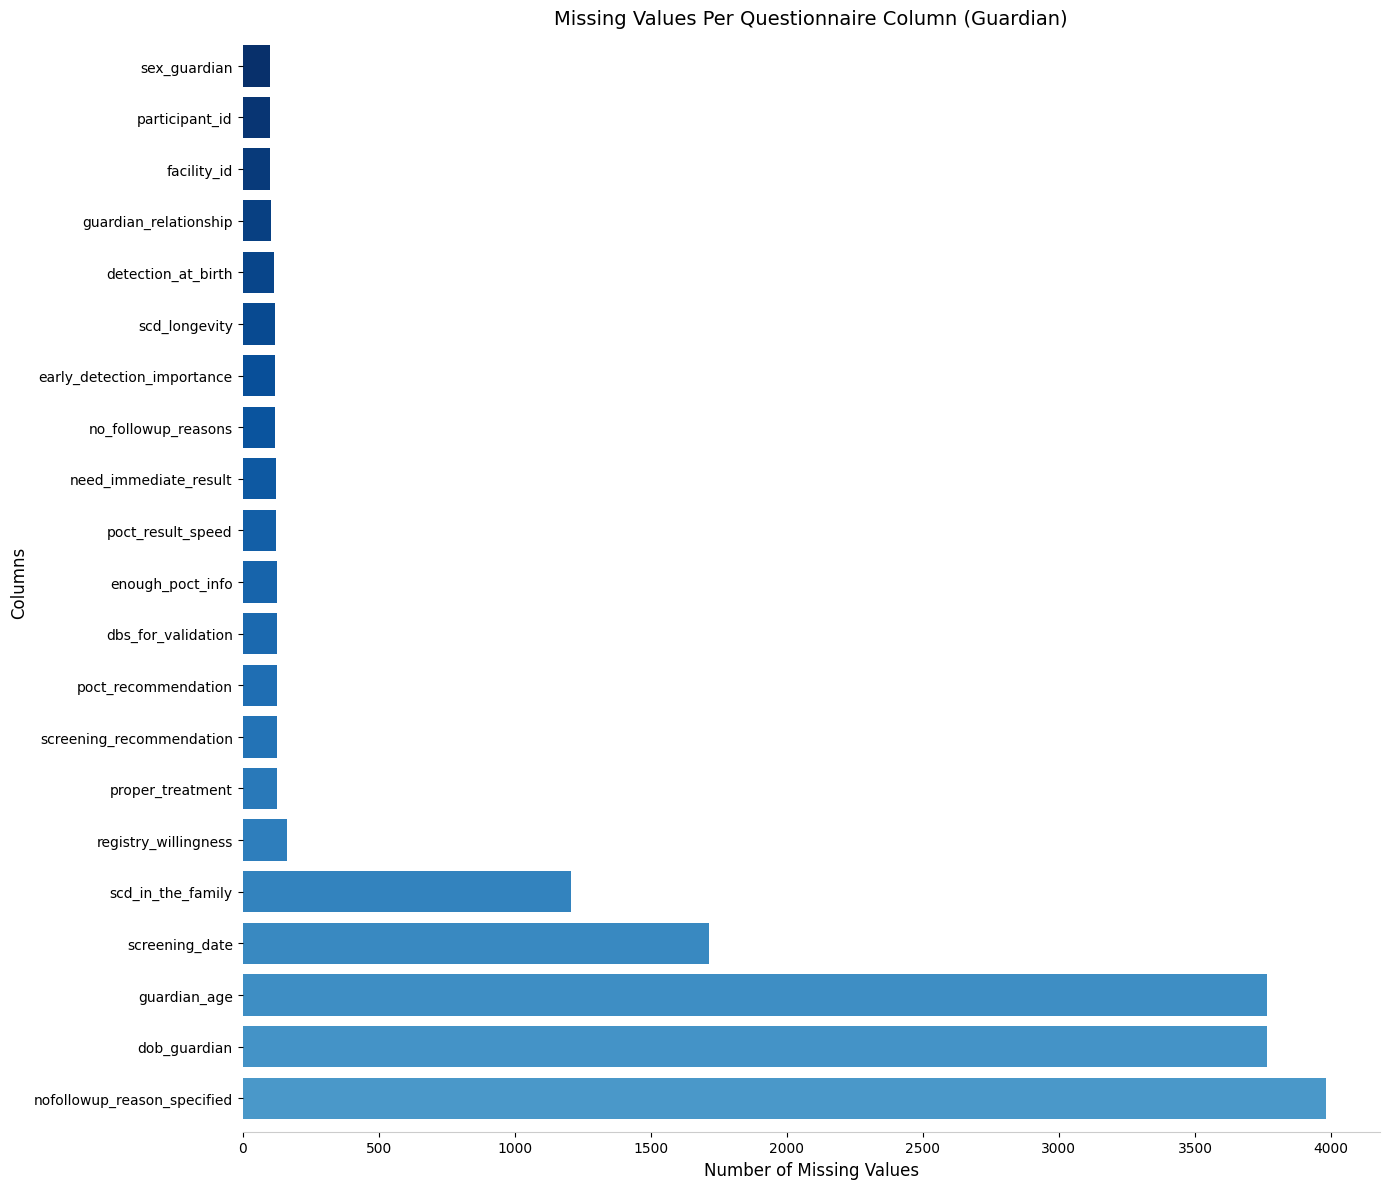

In [39]:
# Count missing values in each column
missing_summary = df_questionnaire.isnull().sum()

# Filter for columns with missing values
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

# Create a color gradient (blue shades)
colors = plt.cm.Blues(np.linspace(0.6, 1, len(missing_summary)))

# Adjust figure size for more vertical space
plt.figure(figsize=(14, 12))  # Increased height

# Plot missing values as a horizontal bar chart
missing_summary.plot(kind='barh', color=colors, width=0.8)  # Thicker bars

# Modern styling
plt.title('Missing Values Per Questionnaire Column (Guardian)', fontsize=14)
plt.xlabel('Number of Missing Values', fontsize=12)
plt.ylabel('Columns', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Remove borders around bars
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_color('#cccccc')  # Light gray bottom border for subtle styling

# Improve layout
plt.tight_layout()

# Save the plot as a file
plt.savefig("figures/eda/missing_values_questionnaire.png", dpi=300, bbox_inches='tight')  # Save as PNG with high resolution

# Show the plot
plt.show()

In [40]:
country_remap = {
    'Zim_zam': 'Zimbabwe/Zambia'
    # add more remaps here if needed
}

# Build actual counts from df_questionnaire
actual_series = (
    df_questionnaire['country']
      .map(country_remap)
      .fillna(df_questionnaire['country'])
      .value_counts()
)

actual_df = actual_series.rename_axis('Country').reset_index(name='Actual')
actual_df

,Country,Actual
0,Zimbabwe/Zambia,1000
1,Ghana,999
2,Uganda,980
3,Tanzania,900
4,Mali,104


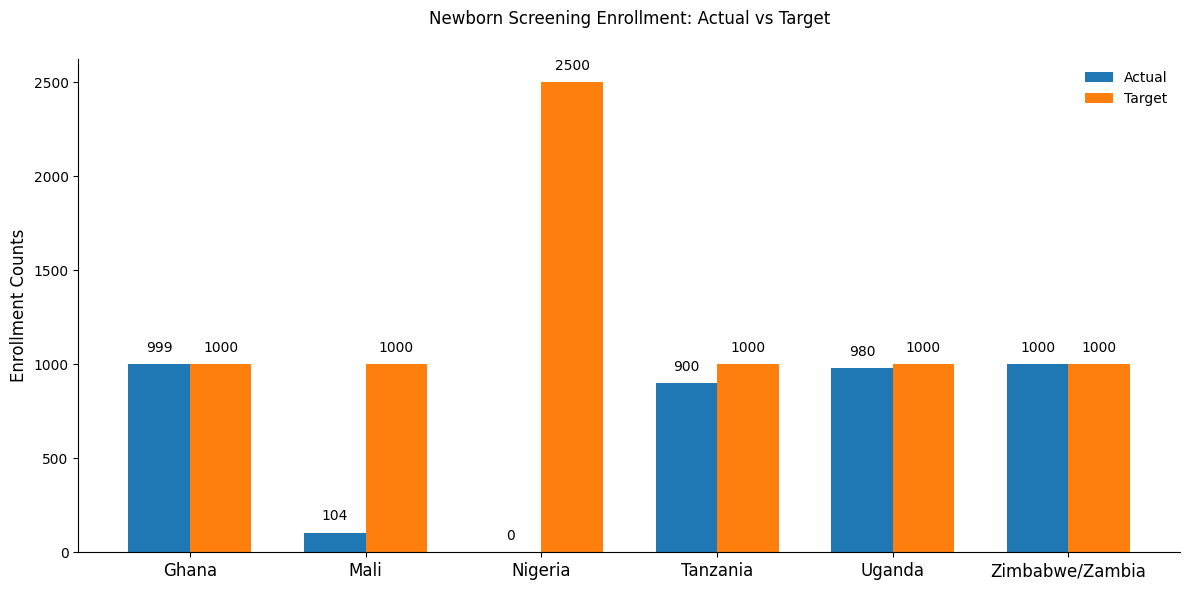

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- derive Actual from dataset ---
# Remap country labels from the dataset to display names
country_remap = {
    'Zim_zam': 'Zimbabwe/Zambia'
    # add more remaps here if needed
}

# Build actual counts from df_questionnaire
actual_series = (
    df_questionnaire['country']
      .map(country_remap)
      .fillna(df_questionnaire['country'])
      .value_counts()
)

actual_df = actual_series.rename_axis('Country').reset_index(name='Actual')

# --- targets (keep your goals) ---
target_data = {
    "Ghana": 1000,
    "Mali": 1000,
    "Nigeria": 2500,          # will show 0 actual if not present in data
    "Tanzania": 1000,
    "Uganda": 1000,
    "Zimbabwe/Zambia": 1000
}

# Desired order on the x-axis
order = ["Ghana", "Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]

# Assemble final plotting table (include all in `order`; fill missing actual with 0)
df = pd.DataFrame({"Country": order})
df = df.merge(actual_df, on="Country", how="left")
df["Actual"] = df["Actual"].fillna(0).astype(int)
df["Target"] = df["Country"].map(target_data)

# ---- Plot ----
x = np.arange(len(df["Country"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, df["Actual"], width, label="Actual")
bars2 = ax.bar(x + width/2, df["Target"], width, label="Target")

for rect, cnt in zip(bars1, df["Actual"]):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + max(df["Target"])*0.02,
            f"{cnt}", ha="center", va="bottom", fontsize=10)

for rect, cnt in zip(bars2, df["Target"]):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + max(df["Target"])*0.02,
            f"{cnt}", ha="center", va="bottom", fontsize=10)

ax.grid(visible=False, which='both', axis='both')
ax.xaxis.grid(False)
ax.yaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Enrollment Counts", fontsize=12)
ax.set_title("Newborn Screening Enrollment: Actual vs Target", pad=25)
ax.title.set_y(1.02)  
ax.set_xticks(x)
ax.set_xticklabels(df["Country"], fontsize=12)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/eda/enrollment_actual_vs_target_clean.png", dpi=600, bbox_inches="tight")
plt.show()

In [42]:
df_questionnaire.head()

,record_id,participant_id,facility_id,screening_date,dob_guardian,guardian_age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,GH1,ML001,GH001,2024-02-20,1996-12-10,27.2,Female,Mother,Neutral,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
1,GH2,ML002,GH001,2024-02-20,NaT,NaN,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,Ghana
2,GH3,ML003,GH001,2024-02-20,NaT,NaN,Female,Mother,Neutral,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
3,GH4,ML004,GH001,2024-02-20,NaT,NaN,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
4,GH5,ML005,GH001,2024-02-21,1993-01-01,31.1,Female,Mother,Agree,Neutral,Neutral,Neutral,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,Ghana


In [43]:
df_questionnaire['country'].value_counts(dropna=False)

country
Zimbabwe/Zambia    1000
Ghana               999
Uganda              980
Tanzania            900
Mali                104
Name: count, dtype: int64

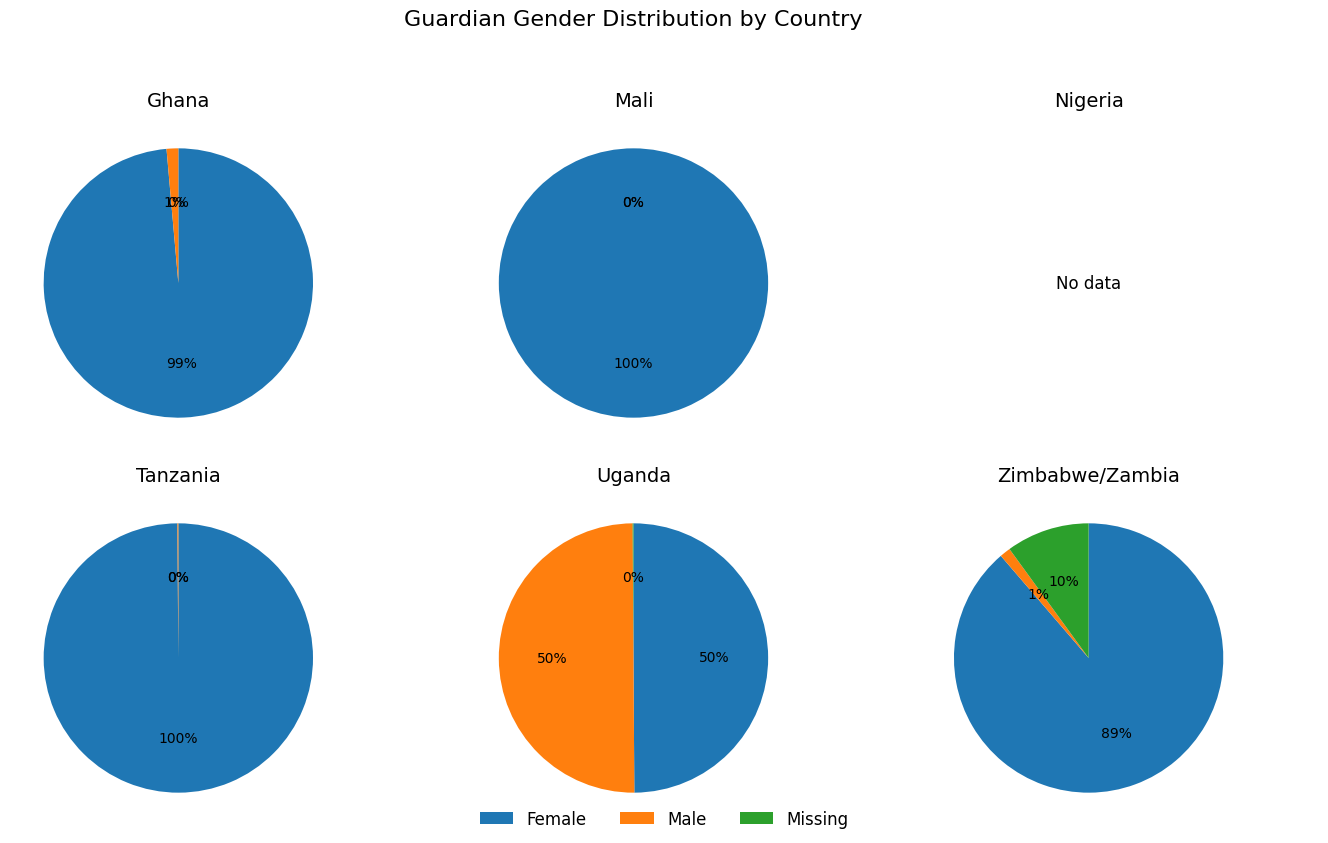

In [44]:
country_remap = {'Zim_zam': 'Zimbabwe/Zambia'}
dfp = df_questionnaire.copy()
dfp['Country'] = dfp['country'].map(country_remap).fillna(dfp['country'])

def _norm_sex(x):
    if pd.isna(x):
        return np.nan
    # numeric codes 0/1 → Male/Female
    sx = str(x).strip()
    if sx in ('0', '1'):
        return 'Male' if sx == '0' else 'Female'

    s = sx.lower()
    if s in ('m', 'male'):   return 'Male'
    if s in ('f', 'female'): return 'Female'
    return np.nan

dfp['sex_norm'] = dfp['sex_guardian'].apply(_norm_sex).astype('object')
dfp['sex_norm'] = dfp['sex_norm'].fillna('Missing')

counts = (
    dfp.groupby(['Country', 'sex_norm'])
       .size()
       .unstack(fill_value=0)
)

# Ensure expected columns exist and order them
for col in ['Female', 'Male', 'Missing']:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[['Female', 'Male', 'Missing']]

# Desired country order on the grid
order = ["Ghana", "Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]
counts = counts.reindex(order, fill_value=0)

# --- plot pies (2x3 grid) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

labels = ["Female", "Male", "Missing"]
wedges_for_legend = None

for i, country in enumerate(order):
    ax = axes[i]
    vals = counts.loc[country, labels].values
    total = vals.sum()

    if total == 0:
        ax.axis('off')
        ax.set_title(country, fontsize=14)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)
        continue

    wedges, texts, autotexts = ax.pie(
        vals, autopct="%1.0f%%", startangle=90, counterclock=False
    )
    ax.set_title(country, fontsize=14)

    if wedges_for_legend is None:
        wedges_for_legend = wedges  # capture handles for legend

# One global legend
if wedges_for_legend is not None:
    fig.legend(wedges_for_legend, labels, loc="lower center", ncol=3, frameon=False, fontsize=12)

plt.suptitle("Guardian Gender Distribution by Country", fontsize=16, y=1.04)
plt.tight_layout()
plt.savefig("figures/eda/guardian_sex_pies_combined_biglegend.png", dpi=300, bbox_inches="tight")
plt.show()

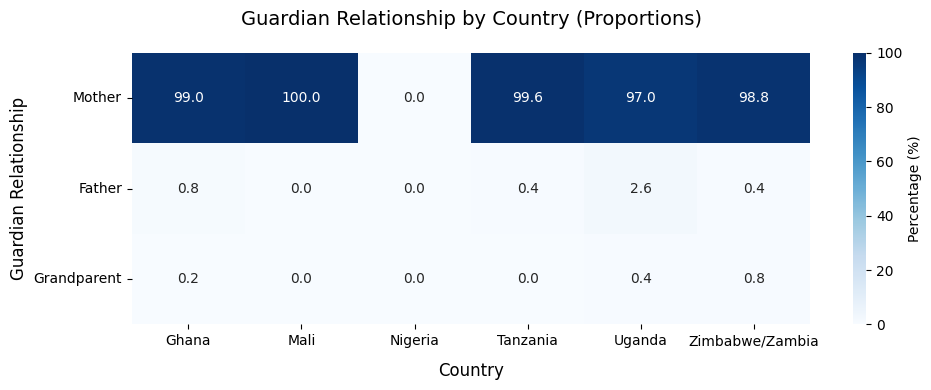

In [45]:
country_remap = {'Zim_zam': 'Zimbabwe/Zambia'}

# Which guardian relationships to include (match your example)
REL_KEEP = ['Mother', 'Father', 'Grandparent']

# Desired country order on the x-axis
COUNTRY_ORDER = ["Ghana", "Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]

# --- Build counts from the dataset ---
dfp = df_questionnaire.copy()
dfp['Country'] = dfp['country'].map(country_remap).fillna(dfp['country'])

# Keep only the relationships you want to plot
mask = dfp['guardian_relationship'].isin(REL_KEEP)
counts = (
    dfp.loc[mask]
       .groupby(['Country', 'guardian_relationship'])
       .size()
       .unstack(fill_value=0)
)

# Ensure all three columns exist, in the desired order
for col in REL_KEEP:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[REL_KEEP]

# Ensure all six countries appear, fill with 0 if missing
counts = counts.reindex(COUNTRY_ORDER, fill_value=0)

# --- Convert to percentages across each country (row) ---
row_totals = counts.sum(axis=1)
df_perc = (counts.div(row_totals.replace(0, np.nan), axis=0) * 100).fillna(0.0)

# Transpose so relationships are on Y axis
df_perc_T = df_perc.T

# --- Plot heatmap ---
plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_perc_T, annot=True, fmt=".1f", cmap="Blues",
    cbar_kws={'label': 'Percentage (%)'}
)

ax.set_title("Guardian Relationship by Country (Proportions)", fontsize=14, pad=20)
ax.set_ylabel("Guardian Relationship", fontsize=12)
ax.set_xlabel("Country", fontsize=12, labelpad=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("figures/eda/guardian_relationship_heatmap_horizontal_labels.png", dpi=300, bbox_inches="tight")
plt.show()

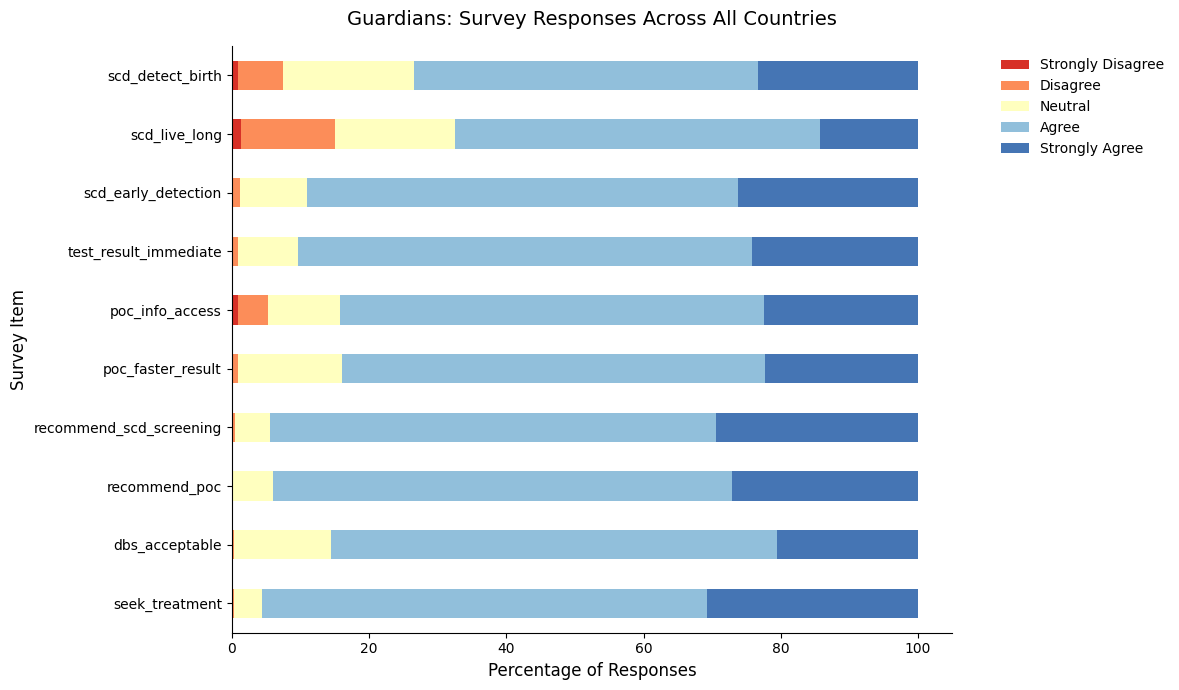

In [46]:
# --- Map item codes → dataframe columns ---
code_to_col = {
    "scd_detect_birth":        "detection_at_birth",
    "scd_live_long":           "scd_longevity",
    "scd_early_detection":     "early_detection_importance",
    "test_result_immediate":   "need_immediate_result",
    "poc_info_access":         "enough_poct_info",
    "poc_faster_result":       "poct_result_speed",
    "recommend_scd_screening": "screening_recommendation",
    "recommend_poc":           "poct_recommendation",
    "dbs_acceptable":          "dbs_for_validation",
    "seek_treatment":          "proper_treatment",
}

# Only keep items whose columns exist
code_to_col = {k: v for k, v in code_to_col.items() if v in df_questionnaire.columns}

likert_levels = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]

# --- Build counts per item (across all countries) ---
rows = []
for code, col in code_to_col.items():
    s = df_questionnaire[col]
    row = {"Item": code}
    # counts for each Likert level
    total_non_missing = s.notna().sum()
    for lvl in likert_levels:
        row[lvl] = (s == lvl).sum()
    row["Missing"] = s.isna().sum()
    row["_total_non_missing"] = total_non_missing
    rows.append(row)

df_counts = pd.DataFrame(rows)

# --- Convert to percentages (excluding missing) ---
df_percent = df_counts.copy()
for lvl in likert_levels:
    df_percent[lvl] = np.where(
        df_counts["_total_non_missing"] > 0,
        df_counts[lvl] / df_counts["_total_non_missing"] * 100.0,
        0.0
    )

# --- Order items & reverse so first appears at top ---
order = [
    "scd_detect_birth", "scd_live_long", "scd_early_detection",
    "test_result_immediate", "poc_info_access", "poc_faster_result",
    "recommend_scd_screening", "recommend_poc",
    "dbs_acceptable", "seek_treatment"
]
order = [c for c in order if c in df_percent["Item"].values]  # guard if some missing
df_percent = df_percent.set_index("Item").loc[order]
df_percent = df_percent.iloc[::-1]  # put first item at top

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#d73027", "#fc8d59", "#ffffbf", "#91bfdb", "#4575b4"]  # same palette
df_percent[likert_levels].plot(kind="barh", stacked=True, ax=ax, color=colors)

ax.set_xlabel("Percentage of Responses", fontsize=12)
ax.set_ylabel("Survey Item", fontsize=12)
ax.set_title("Guardians: Survey Responses Across All Countries", fontsize=14, pad=15)

# Clean up
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)  # ensure no grid lines

# Legend (no title)
ax.legend(title=None, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("figures/eda/likert_combined_all_countries_top_scd_detect_birth.png", dpi=300, bbox_inches="tight")
plt.show()

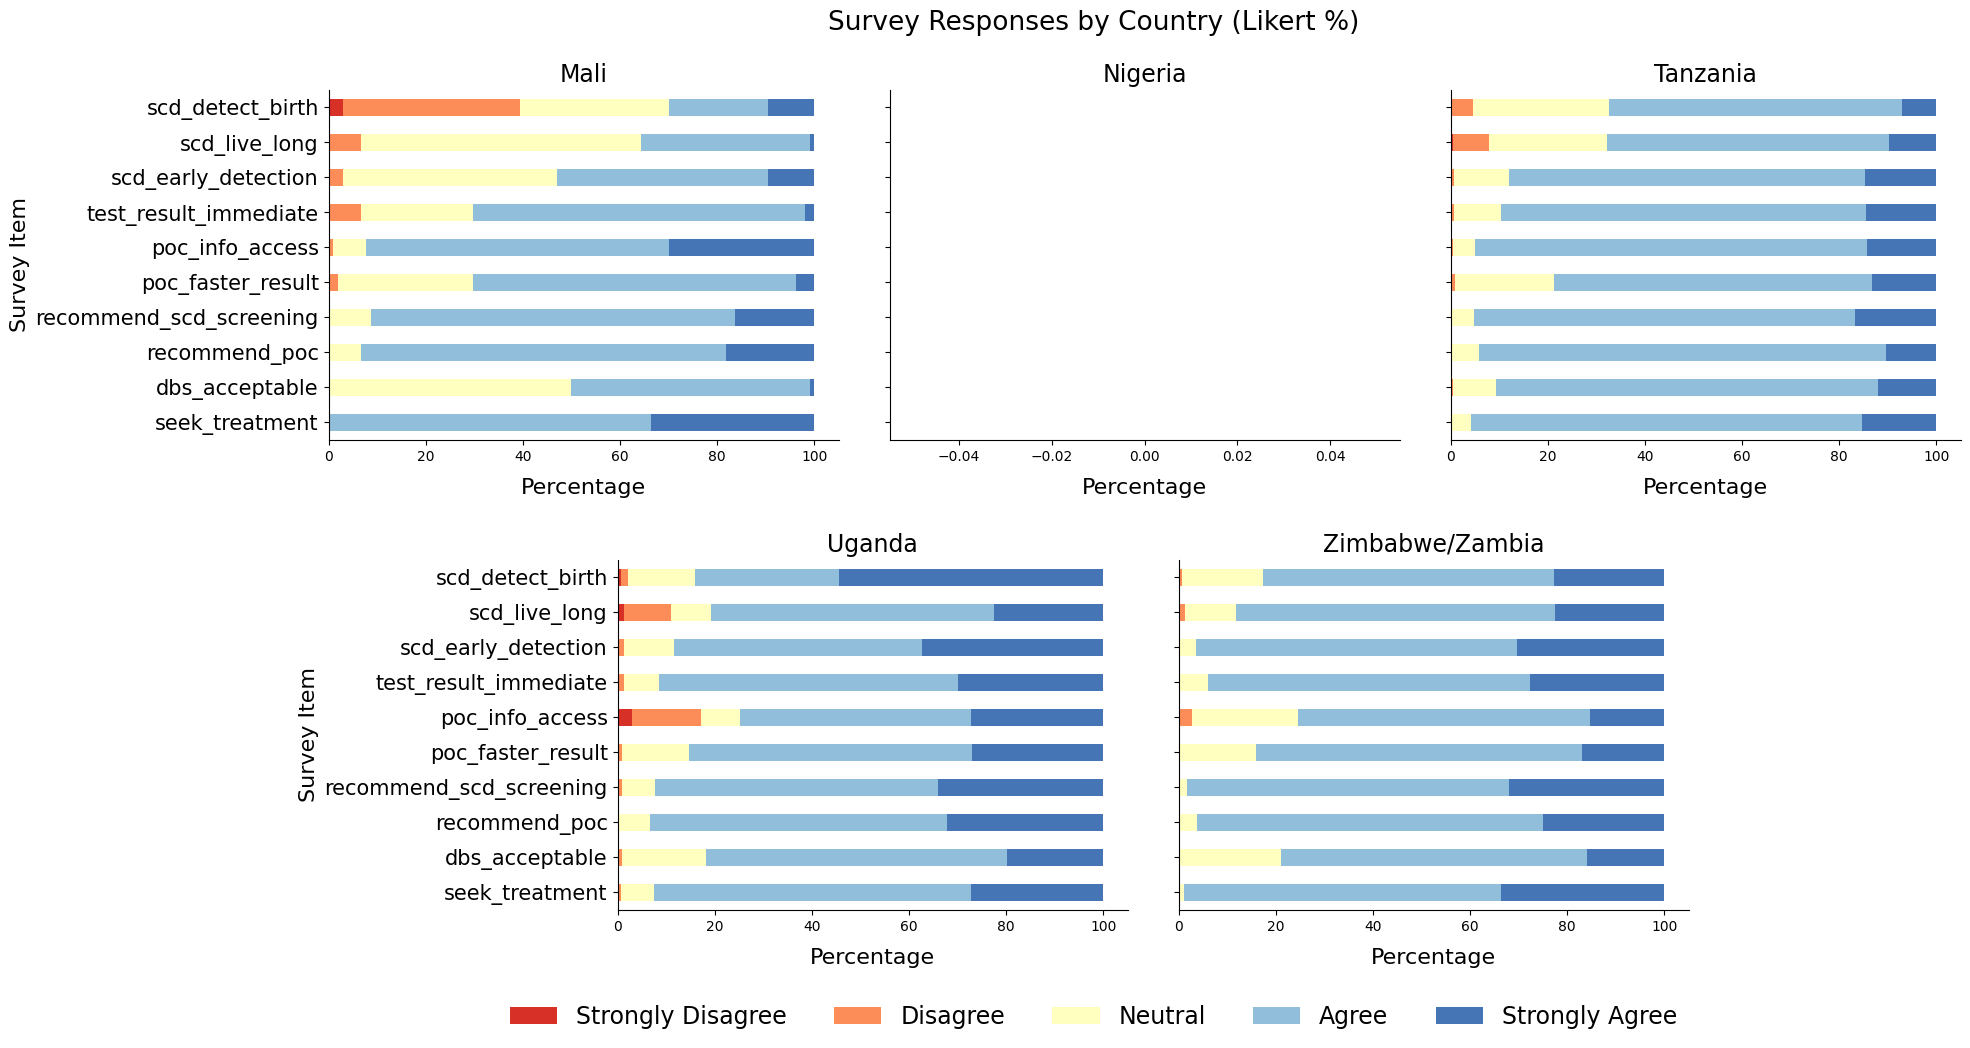

In [47]:
CODE_TO_COL = {
    "scd_detect_birth":        "detection_at_birth",
    "scd_live_long":           "scd_longevity",
    "scd_early_detection":     "early_detection_importance",
    "test_result_immediate":   "need_immediate_result",
    "poc_info_access":         "enough_poct_info",
    "poc_faster_result":       "poct_result_speed",
    "recommend_scd_screening": "screening_recommendation",
    "recommend_poc":           "poct_recommendation",
    "dbs_acceptable":          "dbs_for_validation",
    "seek_treatment":          "proper_treatment",
}

ORDER = [
    "scd_detect_birth", "scd_live_long", "scd_early_detection",
    "test_result_immediate", "poc_info_access", "poc_faster_result",
    "recommend_scd_screening", "recommend_poc", "dbs_acceptable", "seek_treatment"
]

LIKERT_COLS = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
COLORS = ["#d73027", "#fc8d59", "#ffffbf", "#91bfdb", "#4575b4"]

# Countries to plot in your layout order
COUNTRIES = ["Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]

# Remap dataset country labels to display names
COUNTRY_REMAP = {"Zim_zam": "Zimbabwe/Zambia"}

# -------------------- helpers --------------------
def likert_percent_for_country(dfq: pd.DataFrame, country_label: str) -> pd.DataFrame:
    """
    Compute a Likert % table (rows=items, cols=LIKERT_COLS) for a single country.
    Percentages exclude missing (NaN). Returns rows in ORDER (reversed for barh).
    """
    # Prep: map Zim_zam and select country
    dfp = dfq.copy()
    dfp["Country"] = dfp["country"].map(COUNTRY_REMAP).fillna(dfp["country"])
    sub = dfp[dfp["Country"] == country_label]

    # If no rows for this country, return empty marker
    if sub.empty:
        return pd.DataFrame(columns=LIKERT_COLS, index=list(reversed(ORDER)))

    rows = []
    for code, col in CODE_TO_COL.items():
        if col not in sub.columns:
            # column missing -> treat as 0% everywhere
            rows.append({"Item": code, **{k: 0.0 for k in LIKERT_COLS}, "_n": 0})
            continue
        s = sub[col]
        n_nonmiss = s.notna().sum()
        counts = {lvl: int((s == lvl).sum()) for lvl in LIKERT_COLS}
        if n_nonmiss > 0:
            pct = {lvl: counts[lvl] / n_nonmiss * 100.0 for lvl in LIKERT_COLS}
        else:
            pct = {lvl: 0.0 for lvl in LIKERT_COLS}
        row = {"Item": code, **pct, "_n": n_nonmiss}
        rows.append(row)

    dfpct = pd.DataFrame(rows).set_index("Item").loc[ORDER, LIKERT_COLS]
    # reverse for barh so first item appears at the top
    return dfpct.iloc[::-1]

# -------------------- build per-country tables --------------------
dfs = {cty: likert_percent_for_country(df_questionnaire, cty) for cty in COUNTRIES}

# -------------------- plot (manual layout; same as your example) --------------------
fig = plt.figure(figsize=(17, 10))

# Top row (3)
ax1 = fig.add_axes([0.05, 0.55, 0.3, 0.35])   # Mali
ax2 = fig.add_axes([0.38, 0.55, 0.3, 0.35])   # Nigeria
ax3 = fig.add_axes([0.71, 0.55, 0.3, 0.35])   # Tanzania

# Bottom row (2 centered)
ax4 = fig.add_axes([0.22, 0.08, 0.3, 0.35])   # Uganda
ax5 = fig.add_axes([0.55, 0.08, 0.3, 0.35])   # Zimbabwe/Zambia

axes = [ax1, ax2, ax3, ax4, ax5]

for ax, country in zip(axes, COUNTRIES):
    dff = dfs[country]
    if dff.empty or dff.to_numpy().sum() == 0:
        # No data panel
        ax.axis("off")
        ax.set_title(country, fontsize=17)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)
        continue

    dff[LIKERT_COLS].plot(kind="barh", stacked=True, ax=ax, color=COLORS, legend=False)

    ax.set_title(country, fontsize=17)
    ax.set_xlabel("Percentage", fontsize=16, labelpad=10)
    ax.tick_params(axis="y", labelsize=15)

    # Show y-axis labels only on far-left of each row (Mali, Uganda)
    if country not in ["Mali", "Uganda"]:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Survey Item", fontsize=16)

    # Clean look + no grid lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

# One shared legend at the bottom
fig.legend(LIKERT_COLS, loc="lower center", ncol=5, frameon=False, fontsize=17,
           bbox_to_anchor=(0.5, -0.06))

fig.suptitle("Survey Responses by Country (Likert %)", y=0.98, fontsize=19)
plt.savefig("likert_subplots_centered_manual_from_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
print(df_questionnaire.shape)
df_questionnaire.head()

(3983, 23)


,record_id,participant_id,facility_id,screening_date,dob_guardian,guardian_age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,GH1,ML001,GH001,2024-02-20,1996-12-10,27.2,Female,Mother,Neutral,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
1,GH2,ML002,GH001,2024-02-20,NaT,NaN,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,Ghana
2,GH3,ML003,GH001,2024-02-20,NaT,NaN,Female,Mother,Neutral,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
3,GH4,ML004,GH001,2024-02-20,NaT,NaN,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
4,GH5,ML005,GH001,2024-02-21,1993-01-01,31.1,Female,Mother,Agree,Neutral,Neutral,Neutral,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,Ghana


In [49]:
df_questionnaire.to_excel('../data/clean/clean.xlsx', index=False)